### Introduction to Regression
* Regression is a supervised machine learning technique used to predict a continuous numerical value based on one or more input features.
* the goal of regression is to find the relationship between independent variables(features) and a dependent variable (target).

**Example:**
* Predicting house prices
* Predicting Employee Salaries
* Predicting Stock Prices
* Predicting Sales Revenue

### 1.Linear Regression
* Linear Regression is the simplest regression algorithm that models the relationship between input and output variables using a straight line.
* It assumes that a linear relationship exists between the independent variable and dependent variable.

**Objective:**
* Find the best-fitting straight line that

**Example:**
* Salary=5000 x Experience + 2000
* if experience = 5years
* Salary=(5000 x 5) + 20000 = 45000

### Why do we Need a Cost Function?
* Initially, the model guesses values for slope(m) and intercept(b).
* these guesses

### Mean Squared Error (MSE)
* The Most Common Cost Function for Linear Regression in MSE.

**Formula**
* MSE=Error^2+Error^2+Error^2/n
* Error=Actual Value - Predicted Value

**Steps**
1. Find the Error for Each Prediction.
2. Square each error.
3. Add all Squared errors.
4. Divide by the total number of observations.

**Example**
| Actual | Predicted | Error | Error^2 |
|--------|-----------|-------|---------|
| 10 | 8 | 2 | 4 |
| 15 | 14 | 1 | 1 |
| 20 | 

### Gradient Descent
* Gradient Descent is a method used to find the best line by reducing the prediction error step by step.

**Real-Life Example**
* Imagine you are on top of a mountain and want to reach the lowest point.

1. Take a Small Step downward.
2. Check if you're getting lower.
3. Keep taking small Steps down.
4. Eventually,you reach the bottom.


**In Machine Learning**
* Start with random values for slope and intercept.
* Make Predictions.
* Calculate the error using cost function.
* Adjust the values slightly to reduce the error.
* Repeat until the error becomes very small.

In [1]:
import numpy as np

# Dataset
X=np.array([1,2,3,4])
y=np.array([3,5,7,9])

# Initial Values
m=0   # Start with random guesses
b=0

learning_rate=0.01  # Controls how much the model updates each step.
epochs=1000         # Number of iterations

n=len(X)

for i in range(epochs):

    # Predictions
    y_pred=m*X+b    # Current Line Equation.
    
    # Gradients
    dm= (-2/n)*np.sum(X*(y-y_pred))          # How much to change slope
    db=(-2/n)*np.sum(y-y_pred)               # How much to change intercept

    # Update Parameters
    m=m-learning_rate*dm
    b=b-learning_rate*db         # Move toward Lower Error.

print("Slope (m):",m)
print("Intercept (b):",b)

Slope (m): 2.0048610156782556
Intercept (b): 0.9857080211211781


### OLS (Ordinary Least Squares)
* when we draw a regression line, there can be many possible lines.
* OLS helps us find the best line.

#### How?
1. Predict Values using a line.
2. Compare Predicted Values with Actual Values.
3. Find the Error.
4. Square all errors.
5. Add them together.
6. Choose the line with the smallest total error.


In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression

#Sample Data

df=pd.DataFrame({
    'Experience':[2,1,3,7,4,5,6],
    'Salary':[35000,30000,40000,60000,45000,50000,55000]
})

#Input Feature (X)
X=df[['Experience']]

# Target Variable (y)
y=df['Salary']


# Create Model
model=LinearRegression()

# Train Model (OLS happens Here)
model.fit(X,y)

# Predict Salary
predictions=model.predict(X)

# Results
print("Slope:",model.coef_[0])
print("Intercept:",model.intercept_)
print("Predicted Salaries:",predictions)

# When fit() runs, OLS Automatically calculates the best slope and 

Slope: 5000.0
Intercept: 25000.0
Predicted Salaries: [35000. 30000. 40000. 60000. 45000. 50000. 55000.]


In [3]:
new_experience=pd.DataFrame({'Experience':[8,9,10]})
new_predictions=model.predict(new_experience)
print("Predicted Salaries for 8,9,10:")
print(new_predictions)

Predicted Salaries for 8,9,10:
[65000. 70000. 75000.]


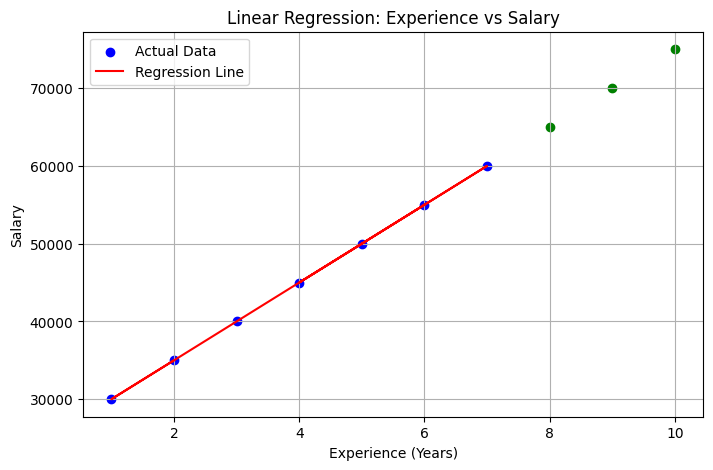

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

# Original data points
plt.scatter(df['Experience'], df['Salary'], color='blue', label='Actual Data')
# Regression line (trained data)
plt.plot(df['Experience'], predictions, color='red', label='Regression Line')
# New predictions
plt.scatter(new_experience['Experience'], new_predictions, color='green')
# Labels
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.title("Linear Regression: Experience vs Salary")
plt.legend()
plt.grid()
plt.show()

###  Multiple Regression
* Multiple Regression is a Regression technique that uses two or more independent variables to predict a dependent variable.

**Example:**
* Predicting a house price using:
1. Area
2. Number of Bedrooms
3. House Age

* Instead of one feature, we use multiple features.

In [5]:
##Multiple Regression Code

import pandas as pd
from sklearn.linear_model import LinearRegression

# Dataset
df = pd.DataFrame({
    'Area':[1000,1200,1500,1800,2000],
    'Bedrooms':[2,3,3,4,4],
    'Age':[10,8,5,4,2],
    'Price':[300000,350000,450000,500000,600000]
})

# Features
X = df[['Area','Bedrooms','Age']]   #Using multiple features.

# Target
y = df['Price']

# Model
model = LinearRegression()

# Train
model.fit(X,y)   #Learns the relationship between all features and price.

# Prediction
pred = model.predict(X)   #predict house price
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [   250.         -34615.38461538 -13461.53846154]
Intercept: 253846.1538461541


In [6]:
new_area=pd.DataFrame({'Area':[2200,2400],
                       'Bedrooms':[4,5],
                       'Age':[1,3]})
new_predictions=model.predict(new_area)
print(new_predictions)

[651923.07692308 640384.61538462]


In [7]:
new_area1=pd.DataFrame({'Area':[2500,29000],
                       'Bedrooms':[6,7],
                       'Age':[1,3]})
new_predictions1=model.predict(new_area1)
print(new_predictions1)

[ 657692.30769231 7221153.84615384]


### 3.Polynomial Regression
* Polynomial Regression is an extension of Linear Regression that captures non-linear relationships by adding polynomial terms.

#### why polynomial regression?
* Not all relationships are straight lines.

#### Examples:
1. Age vs Income
2. Advertising Spend vs Sales
3. Temperature vs Electricity Consumption

* These Relationships

* 

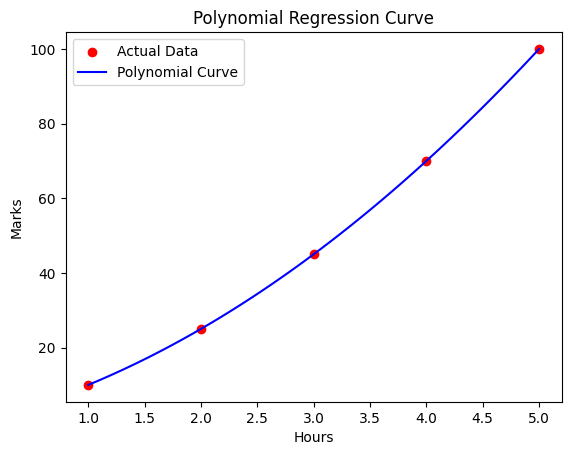

In [8]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression

# Sample dataset

df = pd.DataFrame({

    'Hours': [1, 2, 3, 4, 5],

    'Marks': [10, 25, 45, 70, 100]

})

X = df[['Hours']]

y = df['Marks']

# Polynomial transformation

poly = PolynomialFeatures(degree=4)

X_poly = poly.fit_transform(X)

# Model training

model = LinearRegression()

model.fit(X_poly, y)

# Smooth curve generation (IMPORTANT STEP)

X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

X_range = pd.DataFrame(X_range, columns=['Hours'])

X_range_poly = poly.transform(X_range)

# Predictions for curve

y_curve = model.predict(X_range_poly)

# Plotting

plt.scatter(X, y, color='red', label='Actual Data')

plt.plot(X_range, y_curve, color='blue', label='Polynomial Curve')

plt.title('Polynomial Regression Curve')

plt.xlabel('Hours')

plt.ylabel('Marks')

plt.legend()

plt.show()

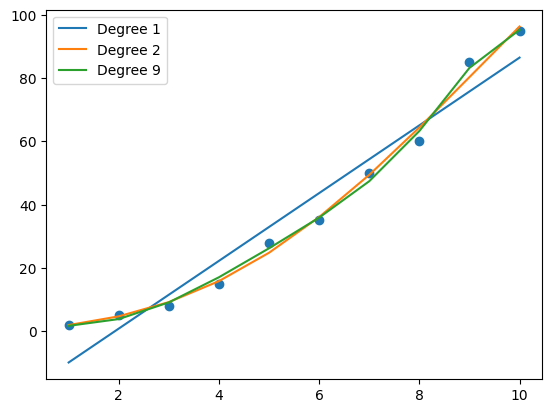

In [9]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression

X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)

y = np.array([2,5,8,15,28,35,50,60,85,95])

# Degree 1

poly1 = PolynomialFeatures(degree=1)

X1 = poly1.fit_transform(X)

# Degree 2

poly4 = PolynomialFeatures(degree=4)

X4 = poly4.fit_transform(X)

# Degree 9

poly9 = PolynomialFeatures(degree=7)

X9 = poly9.fit_transform(X)

model1 = LinearRegression().fit(X1,y)

model4 = LinearRegression().fit(X4,y)

model9 = LinearRegression().fit(X9,y)

plt.scatter(X,y)

plt.plot(X, model1.predict(X1), label="Degree 1")

plt.plot(X, model4.predict(X4), label="Degree 2")

plt.plot(X, model9.predict(X9), label="Degree 9")

plt.legend()

plt.show()

* Degree 1 -> Underfitting - Straight Line Misses the Pattern
* Degree 4 -> Good Fit - Captures the Overall Curve
* Degree 9 -> Overfitting - Tries to Pass through every Point - Learns Noise Instead of Pattern

#### Characteristics
* Shrinks coefficient values towards zero
* Does not make coefficients exactly zero
* Useful when all features are important.
* Handles multicollinearity effectively

### When to use Each Method

| Method | When to Use |
|--------|-------------|
| Ridge | When all features are important and multicollinearity exists. |
| Lasso (L1) | When feature selection is required |
| ElasticNet | When Features are highly correlated and feature selection is also needed |

In [10]:
##Ridge Code

from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression
X, y = make_regression(

    n_samples=100,

    n_features=5,

    noise=20,

    random_state=42

)
ridge = Ridge(alpha=1.0)
ridge.fit(X, y)
print("Coefficients:")
print(ridge.coef_)

Coefficients:
[62.4844981  98.07649112 57.01070157 52.31272567 35.35343002]


In [11]:
##Lasso Code

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
X, y = make_regression(
    n_samples=100,
    n_features=10,
    noise=20,
    random_state=42
)
lasso = Lasso(alpha=2.0)
lasso.fit(X, y)
print("Coefficients:")
print(lasso.coef_)

Coefficients:
[17.88753444 54.76076704  0.         60.9632585  90.0800089  68.30461063
 81.35787563  4.03519677  2.86610797 67.99906953]


In [12]:
##ElasticNet Code

from sklearn.linear_model import ElasticNet
from sklearn.datasets import make_regression
X, y = make_regression(
    n_samples=100,
    n_features=10,
    noise=20,
    random_state=42
)

elastic = ElasticNet(
    alpha=3.0,
    l1_ratio=0.5
)
elastic.fit(X, y)
print("Coefficients:")
print(elastic.coef_)

Coefficients:
[10.65990986 22.10890939  0.49979146 25.9235125  33.08321402 34.26097045
 35.7929364  -7.32756763  4.65692898 25.41452644]
